In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from googleapiclient.discovery import build
from transformers import pipeline
from dotenv import load_dotenv
from datetime import datetime, timezone
from dateutil.relativedelta import relativedelta

/Users/lucas/Projects/ai-bubble/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
load_dotenv()

API_KEY = os.getenv('YOUTUBE_API_KEY') 
SEARCH_QUERY = 'AI Bubble'
MAX_VIDEOS_PER_MONTH = 10
MAX_COMMENTS_PER_VIDEO = 1000    

START_DATE = datetime(2024, 1, 1, tzinfo=timezone.utc)
END_DATE = datetime(2025, 12, 31, tzinfo=timezone.utc)

if not API_KEY:
    print("WARNING: API Key not found. Please check your .env file.")
else:
    print("Configuration loaded. Ready to proceed.")

Configuration loaded. Ready to proceed.


In [ ]:
youtube = build('youtube', 'v3', developerKey=API_KEY)
print("Connected to YouTube API successfully.")

print("Loading emotion analysis model (this might take a moment)...")
emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")
print("Model loaded successfully!")

Connected to YouTube API successfully.
Loading emotion analysis model (this might take a moment)...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 42188.13it/s]


Model loaded successfully!


In [ ]:
def get_video_ids(query, max_results, published_after, published_before):
    """Searches YouTube for the most viewed videos within a specific timeframe."""
    request = youtube.search().list(
        part="id",
        q=query,
        type="video",
        order="viewCount", 
        publishedAfter=published_after.isoformat(),
        publishedBefore=published_before.isoformat(),
        maxResults=max_results
    )
    response = request.execute()
    return [item['id']['videoId'] for item in response.get('items', [])]

def get_video_comments(video_id, max_results):
    """Fetches top comments from a specific video."""
    comments = []
    try:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=max_results,
            textFormat="plainText"
        )
        response = request.execute()
        
        for item in response.get('items', []):
            comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
            comments.append(comment)
    except Exception as e:
        pass
        
    return comments

In [ ]:
all_data = []
current_date = START_DATE

print(f"Starting temporal analysis from {START_DATE.year} to {END_DATE.year}...")

while current_date < END_DATE:
    next_month = current_date + relativedelta(months=1)
    
    month_label = current_date.strftime('%Y-%m')
    print(f"Processing {month_label}...")
    
    # 1. Get top 10 most viewed videos for THIS month
    video_ids = get_video_ids(
        query=SEARCH_QUERY, 
        max_results=MAX_VIDEOS_PER_MONTH, 
        published_after=current_date, 
        published_before=next_month
    )
    
    # 2. Analyze comments for these videos
    if video_ids:
        for video_id in video_ids:
            comments = get_video_comments(video_id, MAX_COMMENTS_PER_VIDEO)
            
            for comment in comments:
                # Truncate to avoid model token limits
                safe_comment = comment[:500] 
                result = emotion_classifier(safe_comment)[0]
                
                all_data.append({
                    "Month": month_label,
                    "Video_ID": video_id,
                    "Comment": comment,
                    "Emotion": result['label'],
                    "Confidence": result['score']
                })
    else:
        print(f"  -> No videos found for {month_label}.")
            
    # Move to the next month
    current_date = next_month

# Create the final DataFrame
df = pd.DataFrame(all_data)
print("\nDone! Analyzed a total of", len(df), "comments across the timeline.")

# Convert 'Month' to an actual datetime object for easier plotting
df['Month'] = pd.to_datetime(df['Month'])

# Display the first few rows
df.head()

Starting temporal analysis from 2024 to 2025...
Processing 2024-01...
Processing 2024-02...
Processing 2024-03...
Processing 2024-04...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (578 > 512). Running this sequence through the model will result in indexing errors


Processing 2024-05...
Processing 2024-06...
Processing 2024-07...
Processing 2024-08...
Processing 2024-09...
Processing 2024-10...
Processing 2024-11...
Processing 2024-12...
Processing 2025-01...
Processing 2025-02...
Processing 2025-03...
Processing 2025-04...
Processing 2025-05...
Processing 2025-06...
Processing 2025-07...
Processing 2025-08...
Processing 2025-09...
Processing 2025-10...
Processing 2025-11...
Processing 2025-12...

Done! Analyzed a total of 20275 comments across the timeline.


,Month,Video_ID,Comment,Emotion,Confidence
0,2024-01-01,EcTUxwa8SME,ydgjfg di dunia 😂,neutral,0.563509
1,2024-01-01,EcTUxwa8SME,Iku anakmu,neutral,0.838673
2,2024-01-01,EcTUxwa8SME,😂😂😂😂😂😂😂😊😊😂😂😂😂😂,neutral,0.729262
3,2024-01-01,EcTUxwa8SME,😮😅😂😂😂😂😂😂😂😂😂😂😂,neutral,0.695195
4,2024-01-01,EcTUxwa8SME,Akujugalagimakanpermenkaret,neutral,0.568258


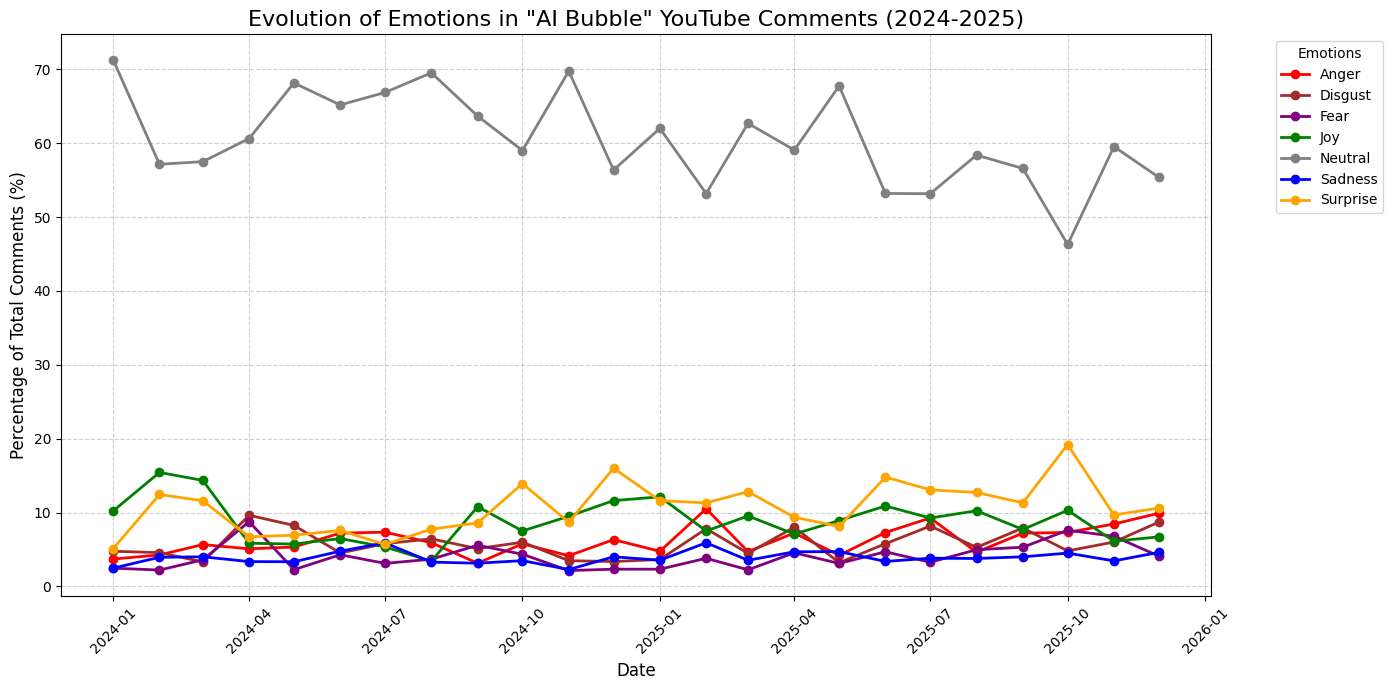

In [6]:
# Group the data by Month and Emotion, then count the occurrences
temporal_data = df.groupby(['Month', 'Emotion']).size().unstack(fill_value=0)

# Normalize the data to see the percentage of emotions per month
temporal_data_pct = temporal_data.div(temporal_data.sum(axis=1), axis=0) * 100

# Plotting
plt.figure(figsize=(14, 7))

# Define consistent colors for the specific emotions
colors = {
    'anger': 'red', 'disgust': 'brown', 'fear': 'purple', 
    'joy': 'green', 'neutral': 'gray', 'sadness': 'blue', 'surprise': 'orange'
}

for emotion in temporal_data_pct.columns:
    plt.plot(
        temporal_data_pct.index, 
        temporal_data_pct[emotion], 
        marker='o', 
        linewidth=2, 
        label=emotion.capitalize(),
        color=colors.get(emotion, 'black')
    )

plt.title(f'Evolution of Emotions in "{SEARCH_QUERY}" YouTube Comments (2024-2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percentage of Total Comments (%)', fontsize=12)
plt.legend(title='Emotions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the graph
plt.show()

In [7]:
import yfinance as yf

TICKER = "NVDA"

print(f"Fetching {TICKER} stock data from {START_DATE.year} to {END_DATE.year}...")

# Download the historical data
# Setting interval="1mo" groups the stock data by month to match your emotion graph
nvda_data = yf.download(
    TICKER, 
    start=START_DATE.strftime('%Y-%m-%d'), 
    end=END_DATE.strftime('%Y-%m-%d'),
    interval="1mo" 
)

print("Data fetched successfully!")

# Display the first few rows to verify the data structure
nvda_data.head()

Fetching NVDA stock data from 2024 to 2025...


[*********************100%***********************]  1 of 1 completed

Data fetched successfully!


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
2024-01-01,61.489414,63.454213,47.291092,49.213917,9706237000
2024-02-01,79.063675,82.343668,61.612343,62.062065,11061356000
2024-03-01,90.300812,97.340508,79.386477,79.951135,12149218000
2024-04-01,86.353279,92.172994,75.563369,90.248085,10072334000
2024-05-01,109.571159,115.753667,81.209161,85.029012,9645174000


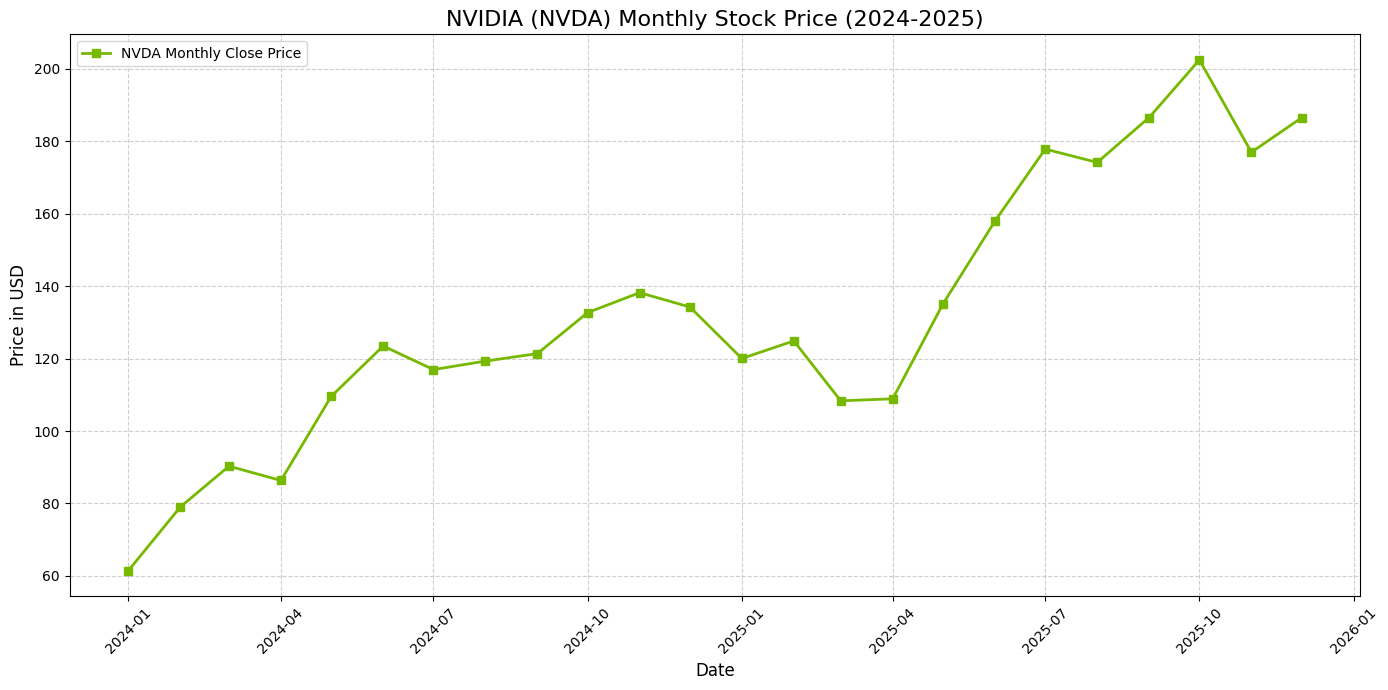

In [8]:
plt.figure(figsize=(14, 7))

# Plot the monthly closing price
plt.plot(
    nvda_data.index, 
    nvda_data['Close'], 
    marker='s',              # Square markers to visually distinguish from the emotion plot
    color='#76b900',         # NVIDIA's brand green
    linewidth=2,
    label='NVDA Monthly Close Price'
)

plt.title('NVIDIA (NVDA) Monthly Stock Price (2024-2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in USD', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the graph
plt.show()

In [10]:
# 1. Flatten the MultiIndex from yfinance to a single level
if isinstance(nvda_data.columns, pd.MultiIndex):
    # This grabs the 'Close' category and renames the underlying 'NVDA' column
    nvda_close = nvda_data['Close'].copy()
    nvda_close.columns = ['NVDA_Price']
else:
    # Fallback for older versions of yfinance
    nvda_close = nvda_data[['Close']].rename(columns={'Close': 'NVDA_Price'})

# 2. Ensure the indexes align perfectly (sometimes timezones get in the way)
temporal_data_pct.index = temporal_data_pct.index.tz_localize(None)
nvda_close.index = nvda_close.index.tz_localize(None)

# 3. Merge the two DataFrames based on their Date indexes
merged_df = temporal_data_pct.join(nvda_close, how='inner')

print("Data merged successfully! Here is a peek:")
merged_df.head()

Data merged successfully! Here is a peek:


,anger,disgust,fear,joy,neutral,sadness,surprise,NVDA_Price
Month,,,,,,,,
2024-01-01,3.697183,4.753521,2.464789,10.211268,71.302817,2.464789,5.105634,61.489414
2024-02-01,4.251969,4.566929,2.204724,15.433071,57.165354,3.937008,12.440945,79.063675
2024-03-01,5.655172,3.310345,3.586207,14.344828,57.517241,4.000000,11.586207,90.300812
2024-04-01,5.081081,9.621622,8.756757,5.837838,60.648649,3.351351,6.702703,86.353279
2024-05-01,5.326232,8.255659,2.263648,5.725699,68.175766,3.328895,6.924101,109.571159


In [11]:
# Calculate the correlation matrix
correlation_matrix = merged_df.corr()

# Extract just how the emotions correlate with the NVIDIA price
nvda_correlations = correlation_matrix['NVDA_Price'].drop('NVDA_Price')

# Sort them to see the strongest correlations at the top
nvda_correlations = nvda_correlations.sort_values(ascending=False)

print("Correlation with NVIDIA Stock Price:\n")
print(nvda_correlations)

Correlation with NVIDIA Stock Price:

anger       0.533590
surprise    0.525557
fear        0.365791
disgust     0.173859
sadness     0.168332
joy        -0.166575
neutral    -0.553173
Name: NVDA_Price, dtype: float64


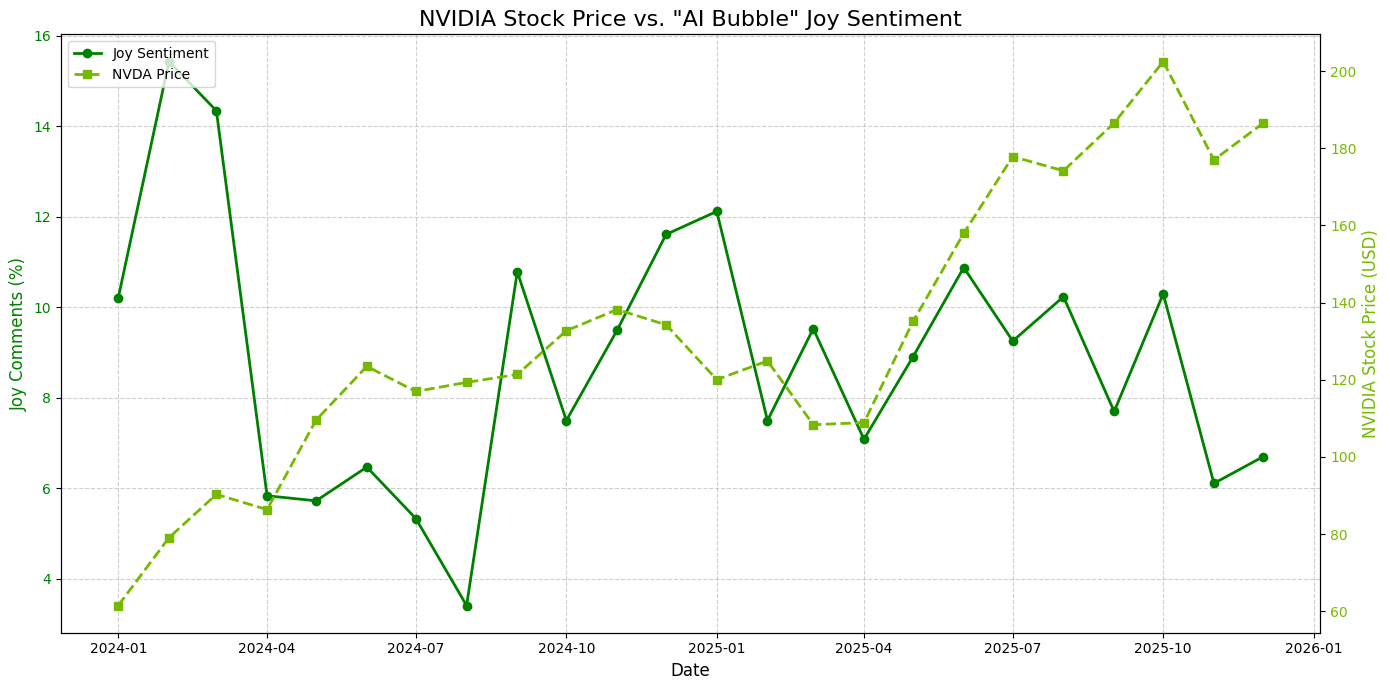

In [15]:
# Let's plot the strongest correlating emotion
TARGET_EMOTION = 'joy'  

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Plot 1: The Emotion (Left Y-Axis) ---
color_emotion = 'green'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel(f'{TARGET_EMOTION.capitalize()} Comments (%)', color=color_emotion, fontsize=12)
ax1.plot(merged_df.index, merged_df[TARGET_EMOTION], color=color_emotion, marker='o', linewidth=2, label=f'{TARGET_EMOTION.capitalize()} Sentiment')
ax1.tick_params(axis='y', labelcolor=color_emotion)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second Y-axis that shares the same X-axis
ax2 = ax1.twinx()  

# --- Plot 2: NVDA Stock (Right Y-Axis) ---
color_stock = '#76b900'
ax2.set_ylabel('NVIDIA Stock Price (USD)', color=color_stock, fontsize=12)
ax2.plot(merged_df.index, merged_df['NVDA_Price'], color=color_stock, marker='s', linewidth=2, linestyle='--', label='NVDA Price')
ax2.tick_params(axis='y', labelcolor=color_stock)

# --- Add the Unified Legend ---
# Extract lines and labels from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine them into a single legend on ax1
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Add titles and adjust layout
plt.title(f'NVIDIA Stock Price vs. "{SEARCH_QUERY}" {TARGET_EMOTION.capitalize()} Sentiment', fontsize=16)
fig.tight_layout()

# Show the dual-axis graph
plt.show()

In [14]:
# Choose a smoothing window (1 = raw data, 2-3 = smoothed trends)
rolling_months = 2

# Apply rolling average to smooth out month-to-month noise
smoothed_df = merged_df.rolling(window=rolling_months, min_periods=1).mean()

# Calculate the correlation matrix on the smoothed data
correlation_matrix = smoothed_df.corr()

# Extract how every emotion correlates specifically with the NVIDIA Stock Price
nvda_correlations = correlation_matrix['NVDA_Price'].drop('NVDA_Price').sort_values(ascending=False)

print(f"--- Pearson Correlation Coefficients (with {rolling_months}-Month Smoothing) ---")
print("Scale: 1.0 (Perfect Positive), -1.0 (Perfect Negative), 0.0 (No Correlation)\n")

for emotion, score in nvda_correlations.items():
    status = "Positive (Moves with Stock)" if score > 0 else "Negative (Inverse Mirror)"
    print(f"{emotion.capitalize():<10} : {score:>6.2f} ({status})")


--- Pearson Correlation Coefficients (with 2-Month Smoothing) ---
Scale: 1.0 (Perfect Positive), -1.0 (Perfect Negative), 0.0 (No Correlation)

Anger      :   0.67 (Positive (Moves with Stock))
Surprise   :   0.66 (Positive (Moves with Stock))
Fear       :   0.54 (Positive (Moves with Stock))
Disgust    :   0.24 (Positive (Moves with Stock))
Sadness    :   0.23 (Positive (Moves with Stock))
Joy        :  -0.23 (Negative (Inverse Mirror))
Neutral    :  -0.68 (Negative (Inverse Mirror))


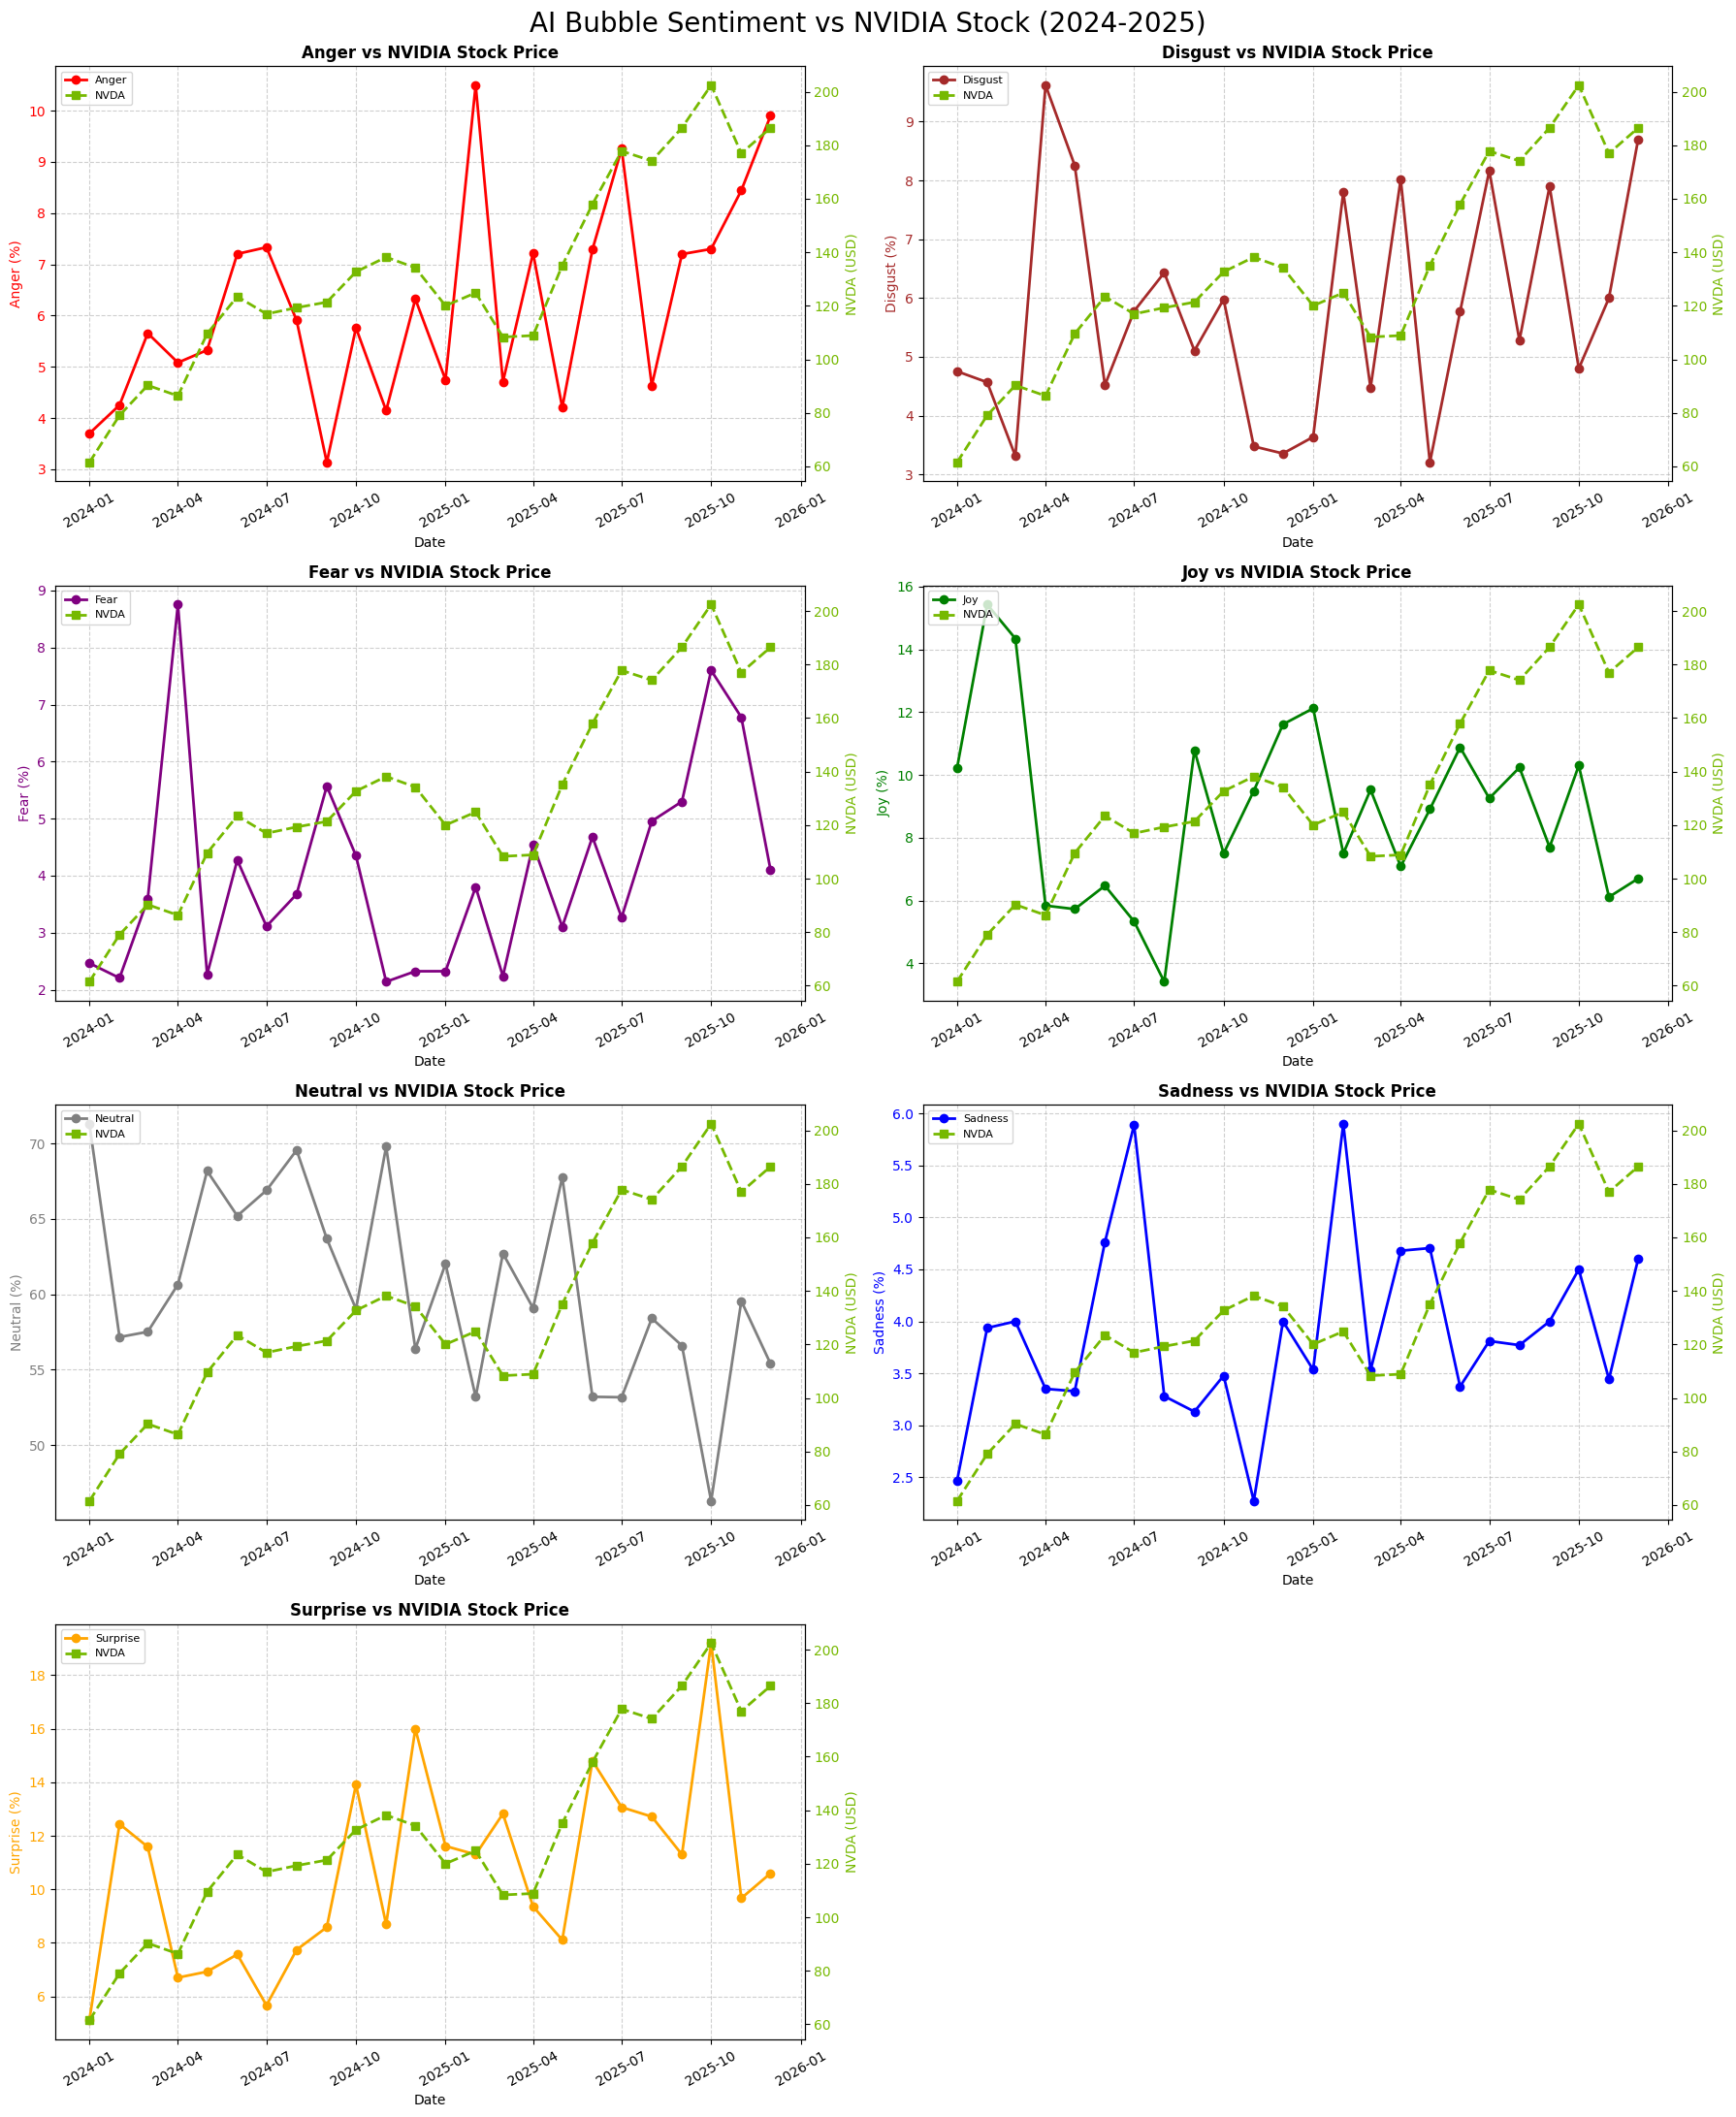

In [24]:
# Extract just the emotion column names
emotions_list = [col for col in merged_df.columns if col != 'NVDA_Price']

# Define our consistent color palette for the emotions
emotion_colors = {
    'anger': 'red', 'disgust': 'brown', 'fear': 'purple', 
    'joy': 'green', 'neutral': 'gray', 'sadness': 'blue', 'surprise': 'orange'
}

# The consistent NVIDIA brand color
color_stock = '#76b900'

# Create a 4x2 grid of subplots (4 rows, 2 columns)
# We set a large figure size so the charts aren't cramped
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 22))

# Flatten the 2D array of axes into a simple 1D list so we can loop through it easily
axes = axes.flatten()

# Loop through each emotion and assign it to a specific subplot axis
for i, emotion in enumerate(emotions_list):
    ax1 = axes[i] # Select the current subplot slot
    color_emotion = emotion_colors.get(emotion, 'black')
    
    # --- Plot 1: The Emotion (Left Y-Axis) ---
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel(f'{emotion.capitalize()} (%)', color=color_emotion, fontsize=10)
    ax1.plot(merged_df.index, merged_df[emotion], color=color_emotion, marker='o', linewidth=2, label=f'{emotion.capitalize()}')
    ax1.tick_params(axis='y', labelcolor=color_emotion)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Create a second Y-axis that shares the same X-axis for this specific subplot
    ax2 = ax1.twinx()  

    # --- Plot 2: NVDA Stock (Right Y-Axis) ---
    ax2.set_ylabel('NVDA (USD)', color=color_stock, fontsize=10)
    ax2.plot(merged_df.index, merged_df['NVDA_Price'], color=color_stock, marker='s', linewidth=2, linestyle='--', label='NVDA')
    ax2.tick_params(axis='y', labelcolor=color_stock)

    # --- Add the Unified Legend ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=8)

    # Add a title to this specific subplot
    ax1.set_title(f'{emotion.capitalize()} vs NVIDIA Stock Price', fontsize=12, fontweight='bold')
    
    # Rotate the date labels slightly so they fit cleanly
    ax1.tick_params(axis='x', rotation=30)

# We only have 7 emotions, but our grid holds 8 plots. 
# This hides the 8th (empty) slot so it looks professional.
axes[7].set_visible(False)

# Add a main title for the entire dashboard
fig.suptitle('AI Bubble Sentiment vs NVIDIA Stock (2024-2025)', fontsize=20, y=0.99)

# Automatically adjust the padding so nothing overlaps
fig.tight_layout()

# Show the master grid!
plt.show()

In [20]:
from pytrends.request import TrendReq
import pandas as pd

print("Connecting to Google Trends...")

# Initialize the pytrends API
# hl='en-US' sets language, tz=360 is US Central Time (standard default)
pytrends = TrendReq(hl='en-US', tz=360)

# Define our parameters
kw_list = [SEARCH_QUERY] # Uses 'AI Bubble' from your Cell 2 configuration
timeframe_str = f"{START_DATE.strftime('%Y-%m-%d')} {END_DATE.strftime('%Y-%m-%d')}"

print(f"Fetching YouTube search interest for '{SEARCH_QUERY}' between {timeframe_str}...")

# Build the payload. 
# gprop='youtube' is the magic parameter that filters strictly for YouTube searches!
pytrends.build_payload(
    kw_list, 
    cat=0, 
    timeframe=timeframe_str, 
    gprop='youtube'
)

# Fetch the interest over time
youtube_trends_df = pytrends.interest_over_time()

if not youtube_trends_df.empty:
    # Drop the 'isPartial' column as we don't need it for the graph
    youtube_trends_df = youtube_trends_df.drop(labels=['isPartial'], axis='columns')
    print("Data fetched successfully!")
    display(youtube_trends_df.head())
else:
    print("No search data found for this specific query and timeframe.")

Connecting to Google Trends...
Fetching YouTube search interest for 'AI Bubble' between 2024-01-01 2025-12-31...
Data fetched successfully!


,AI Bubble
date,
2023-12-31,3
2024-01-07,4
2024-01-14,4
2024-01-21,3
2024-01-28,3


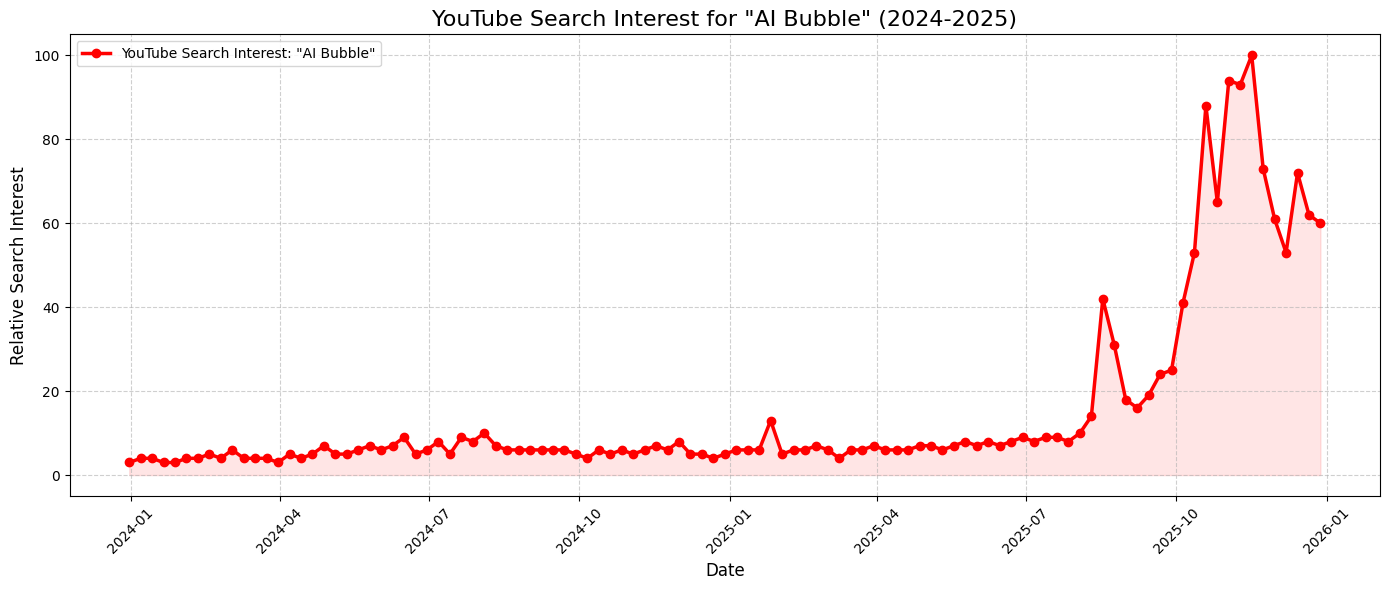

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot the search interest
plt.plot(
    youtube_trends_df.index, 
    youtube_trends_df[SEARCH_QUERY], 
    color='#FF0000', # YouTube Red
    linewidth=2.5,
    marker='o',
    label=f'YouTube Search Interest: "{SEARCH_QUERY}"'
)

# Fill the area under the line slightly for visual impact
plt.fill_between(
    youtube_trends_df.index, 
    youtube_trends_df[SEARCH_QUERY], 
    color='#FF0000', 
    alpha=0.1
)

plt.title(f'YouTube Search Interest for "{SEARCH_QUERY}" (2024-2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Relative Search Interest', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()